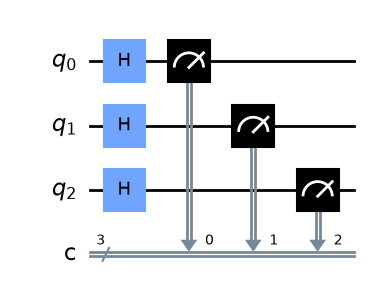

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# 1. Create a 3-qubit circuit with 3 classical bits
qc3 = QuantumCircuit(3, 3)

# 2. Apply Hadamard to all qubits simultaneously
qc3.h([0, 1, 2])
qc3.measure([0, 1, 2], [0, 1, 2])

display(qc3.draw('mpl', style='clifford'))

Theoretical Expectation: 0.125 (1/8) per state
Observed Probabilities: {'000': 0.115234375, '111': 0.1171875, '110': 0.1279296875, '010': 0.12890625, '001': 0.1201171875, '100': 0.138671875, '011': 0.1328125, '101': 0.119140625}


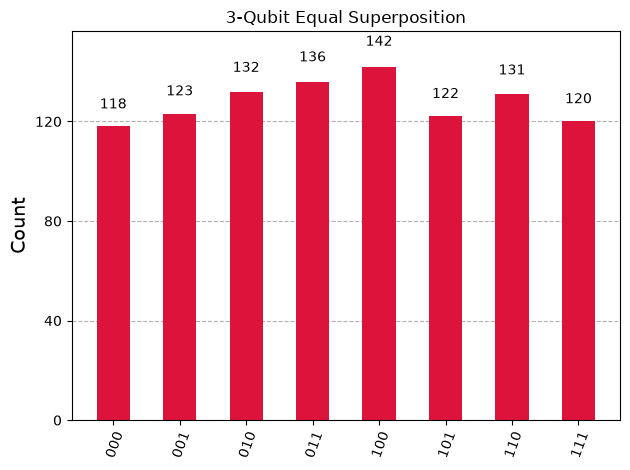

In [2]:
# 3. Execute 1024 shots
simulator = AerSimulator()
compiled_circuit3 = transpile(qc3, simulator)
job3 = simulator.run(compiled_circuit3, shots=1024)
counts3 = job3.result().get_counts()

# 4. Verify probability distribution
probabilities = {state: count / 1024 for state, count in counts3.items()}

print("Theoretical Expectation: 0.125 (1/8) per state")
print("Observed Probabilities:", probabilities)

plot_histogram(counts3, title="3-Qubit Equal Superposition", color='crimson')